# Particle methods: weights, resampling, and ancestry

Sequential Monte Carlo represents a changing distribution by a **weighted population**. The
central difficulty is not drawing points; it is controlling the concentration of the weights
without erasing the evidence that concentration occurred.

This notebook uses only the public `sampler_lab.particles` and `sampler_lab.models`
namespaces. It develops four linked ideas:

1. immutable weighted particle clouds;
2. multinomial, systematic, and floor-plus-Bernoulli resampling;
3. sequential importance sampling for self-avoiding-walk growth;
4. genealogical collapse as a cost of repeated resampling.

**Output semantics:** weighted particles before resampling; approximate unweighted particles
after resampling; unbiased normalizing-constant estimates under the stated proposal rules.

Related pages: [particle-method theory](../methods/particle_methods.md),
[public API](../api.md), and [benchmark semantics](../benchmarking.md).


In [1]:
import importlib.metadata
import os

import matplotlib.pyplot as plt
import numpy as np

from sampler_lab import spawn_rngs
from sampler_lab.models import count_self_avoiding_walks, sample_self_avoiding_walks
from sampler_lab.particles import (
    BernoulliResampler,
    MultinomialResampler,
    ParticleCloud,
    SystematicResampler,
    minimal_conditional_variances,
    multinomial_conditional_variances,
    offspring_counts,
)

QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
SEED = 2022
FIGURE_COUNT = 0


def finish_figure(fig):
    global FIGURE_COUNT
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    FIGURE_COUNT += 1


print("sampler-lab", importlib.metadata.version("sampler-lab"))
print("execution mode:", "quick" if QUICK_MODE else "publication")
print("master seed:", SEED)

sampler-lab 0.12.0
execution mode: publication
master seed: 2022


## 1. A weighted cloud is a probability measure

For particles $x_i$ and normalized weights $W_i$, the empirical measure is

$$
\widehat\pi_N = \sum_{i=1}^N W_i\,\delta_{x_i},
\qquad \sum_i W_i=1.
$$

`ParticleCloud` normalizes supplied log weights, makes both arrays immutable, and exposes
weighted expectations and Kish effective sample size

$$
\operatorname{ESS}_w = \frac{1}{\sum_i W_i^2}.
$$

ESS is a concentration diagnostic, not a claim that the particles are independent.


In [2]:
locations = np.arange(5, dtype=np.float64)[:, None]
raw_weights = np.array([0.04, 0.08, 0.15, 0.23, 0.50])
cloud = ParticleCloud(locations, np.log(raw_weights))
weighted_mean = cloud.expectation(lambda x: x[:, 0])

print("normalized weights:", np.round(cloud.weights, 3))
print("weighted mean:", round(float(weighted_mean), 4))
print("weight ESS:", round(cloud.effective_sample_size, 3), "of", cloud.n_particles)
print("largest normalized weight:", round(cloud.diagnostics.max_normalized_weight, 3))

assert np.isclose(np.sum(cloud.weights), 1.0)
assert np.isclose(weighted_mean, np.dot(raw_weights, locations[:, 0]))

normalized weights: [0.04 0.08 0.15 0.23 0.5 ]
weighted mean: 3.07
weight ESS: 2.999 of 5
largest normalized weight: 0.5


## 2. Resampling is unbiased, but its noise and dependence differ

With target population $N$, unbiased offspring counts satisfy

$$
\mathbb E[N_i\mid W]=NW_i.
$$

Multinomial resampling draws every parent independently and has marginal variance
$NW_i(1-W_i)$. Floor-plus-Bernoulli and systematic resampling attain the minimum possible
marginal variance $r_i(1-r_i)$, where $r_i$ is the fractional part of $NW_i$.

The next experiment repeats each scheme with identical target weights. We expect all three
empirical means to match $NW$, but multinomial variances to be much larger. Systematic and
Bernoulli have similar marginal variances while different joint dependence; Bernoulli also
has a random total population.


In [3]:
weights = np.array([0.035, 0.075, 0.14, 0.25, 0.50])
target_population = 80
repetitions = 700 if QUICK_MODE else 5000
schemes = {
    "multinomial": MultinomialResampler(),
    "systematic": SystematicResampler(),
    "Bernoulli": BernoulliResampler(),
}
scheme_rngs = spawn_rngs(SEED + 10, len(schemes))
count_samples = {}
population_samples = {}

for (name, scheme), rng in zip(schemes.items(), scheme_rngs, strict=True):
    counts = np.empty((repetitions, weights.size), dtype=np.float64)
    totals = np.empty(repetitions, dtype=np.float64)
    for replicate in range(repetitions):
        parents = scheme.resample(weights, rng, target_population)
        counts[replicate] = offspring_counts(parents, weights.size)
        totals[replicate] = parents.size
    count_samples[name] = counts
    population_samples[name] = totals

expected_counts = target_population * weights
empirical_means = {name: values.mean(axis=0) for name, values in count_samples.items()}
empirical_variances = {name: values.var(axis=0) for name, values in count_samples.items()}
multinomial_variance = multinomial_conditional_variances(weights, target_population)
minimal_variance = minimal_conditional_variances(weights, target_population)

for name in schemes:
    max_mean_error = np.max(np.abs(empirical_means[name] - expected_counts))
    print(
        f"{name:>11}: max mean error={max_mean_error:.3f}, "
        f"mean population={population_samples[name].mean():.3f}, "
        f"population sd={population_samples[name].std():.3f}"
    )

multinomial: max mean error=0.022, mean population=80.000, population sd=0.000
 systematic: max mean error=0.005, mean population=80.000, population sd=0.000
  Bernoulli: max mean error=0.004, mean population=79.996, population sd=0.566


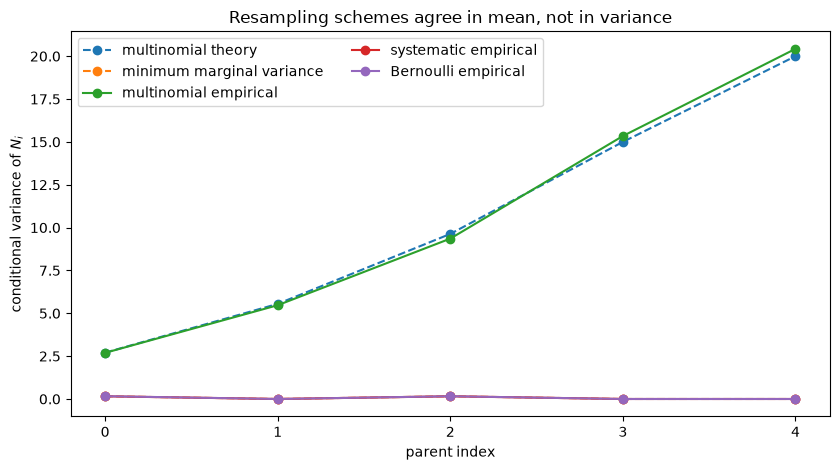

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
parent = np.arange(weights.size)
ax.plot(parent, multinomial_variance, "o--", label="multinomial theory")
ax.plot(parent, minimal_variance, "o--", label="minimum marginal variance")
for name, variances in empirical_variances.items():
    ax.plot(parent, variances, "o-", label=f"{name} empirical")
ax.set_xlabel("parent index")
ax.set_ylabel(r"conditional variance of $N_i$")
ax.set_title("Resampling schemes agree in mean, not in variance")
ax.set_xticks(parent)
ax.legend(ncol=2)
finish_figure(fig)

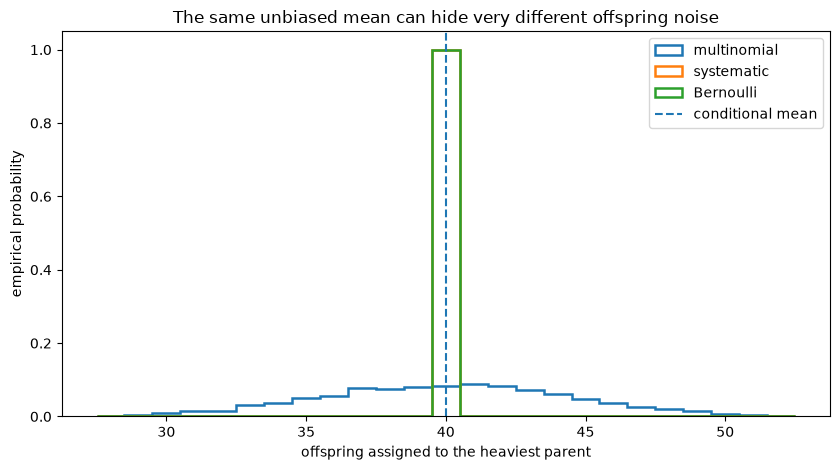

In [5]:
dominant_parent = int(np.argmax(weights))
fig, ax = plt.subplots(figsize=(8.5, 4.8))
bins = np.arange(28, 54) - 0.5
for name, values in count_samples.items():
    ax.hist(
        values[:, dominant_parent],
        bins=bins,
        density=True,
        histtype="step",
        linewidth=1.8,
        label=name,
    )
ax.axvline(expected_counts[dominant_parent], linestyle="--", label="conditional mean")
ax.set_xlabel("offspring assigned to the heaviest parent")
ax.set_ylabel("empirical probability")
ax.set_title("The same unbiased mean can hide very different offspring noise")
ax.legend()
finish_figure(fig)

assert all(
    np.max(np.abs(mean - expected_counts)) < (0.55 if QUICK_MODE else 0.25)
    for mean in empirical_means.values()
)
assert np.mean(empirical_variances["multinomial"]) > 3.0 * np.mean(minimal_variance)

## 3. Sequential importance sampling grows self-avoiding walks

A square-lattice self-avoiding walk grows one vertex at a time. If a partial path has $m_t$
available neighbors, the Rosenbluth proposal selects one uniformly and contributes
incremental weight $m_t$. The product of these factors corrects the biased growth proposal;
averaging the final weights estimates the exact number of walks.

We compare three strategies:

- **SIS:** never resample;
- **resample every step:** systematic resampling after every weighting stage;
- **ESS-triggered:** systematic resampling only when pre-resampling ESS falls below $0.75N$.

The result keeps both `weighted_clouds` and post-resampling `clouds`, so the weight collapse
that triggered a resampling event remains observable.


In [6]:
walk_steps = 8 if QUICK_MODE else 10
n_particles = 1200 if QUICK_MODE else 7000
exact_walk_count = count_self_avoiding_walks(walk_steps)
walk_rngs = spawn_rngs(SEED + 20, 3)
walk_results = {
    "SIS": sample_self_avoiding_walks(walk_rngs[0], n_steps=walk_steps, n_particles=n_particles),
    "systematic every step": sample_self_avoiding_walks(
        walk_rngs[1],
        n_steps=walk_steps,
        n_particles=n_particles,
        resampling="systematic",
        resample_every_step=True,
    ),
    "ESS-triggered systematic": sample_self_avoiding_walks(
        walk_rngs[2],
        n_steps=walk_steps,
        n_particles=n_particles,
        resampling="systematic",
        resample_ess_fraction=0.75,
    ),
}

for name, result in walk_results.items():
    estimate = result.normalizing_constant_estimate
    relative_error = abs(estimate - exact_walk_count) / exact_walk_count
    print(
        f"{name:>25}: estimate={estimate:10.2f}, exact={exact_walk_count}, "
        f"relative error={relative_error:.3%}, "
        f"resampling stages={np.count_nonzero(result.resampled)}"
    )

                      SIS: estimate=  43836.92, exact=44100, relative error=0.597%, resampling stages=0
    systematic every step: estimate=  44448.78, exact=44100, relative error=0.791%, resampling stages=10
 ESS-triggered systematic: estimate=  43981.75, exact=44100, relative error=0.268%, resampling stages=0


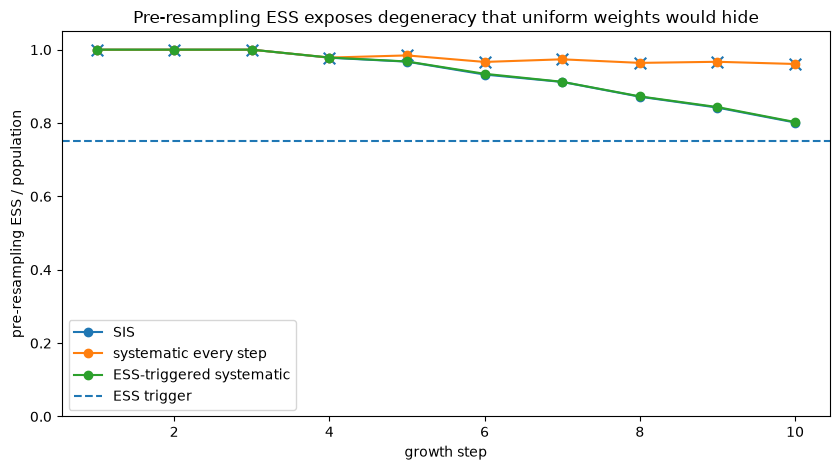

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
stages = np.arange(1, walk_steps + 1)
for name, result in walk_results.items():
    population = np.array(
        [weighted.n_particles for weighted in result.weighted_clouds], dtype=np.float64
    )
    ess_fraction = result.ess_history / population
    ax.plot(stages, ess_fraction, "o-", label=name)
    triggered = np.flatnonzero(result.resampled)
    if triggered.size:
        ax.scatter(stages[triggered], ess_fraction[triggered], marker="x", s=70)
ax.axhline(0.75, linestyle="--", label="ESS trigger")
ax.set_xlabel("growth step")
ax.set_ylabel("pre-resampling ESS / population")
ax.set_ylim(0.0, 1.05)
ax.set_title("Pre-resampling ESS exposes degeneracy that uniform weights would hide")
ax.legend()
finish_figure(fig)

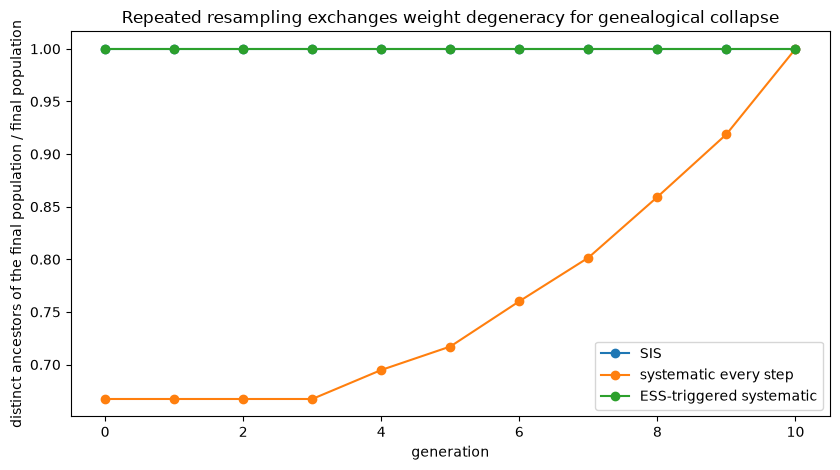

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
generations = np.arange(walk_steps + 1)
for name, result in walk_results.items():
    ancestor_counts = result.ancestry.unique_ancestor_counts()
    ax.plot(generations, ancestor_counts / ancestor_counts[-1], "o-", label=name)
ax.set_xlabel("generation")
ax.set_ylabel("distinct ancestors of the final population / final population")
ax.set_title("Repeated resampling exchanges weight degeneracy for genealogical collapse")
ax.legend()
finish_figure(fig)

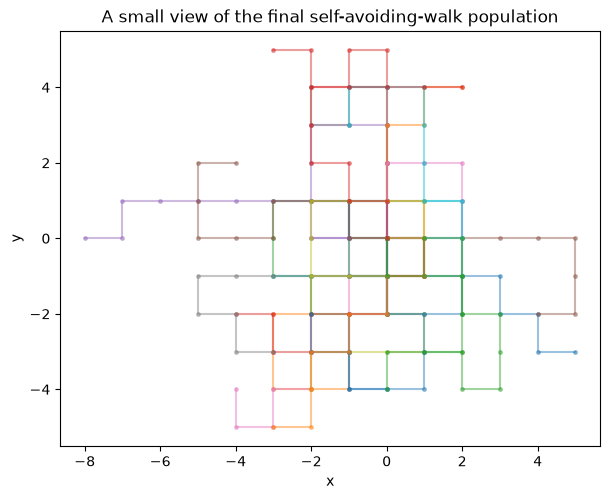

In [9]:
display_result = walk_results["ESS-triggered systematic"]
positive = np.flatnonzero(display_result.final_weighted_cloud.weights > 0.0)
chosen = positive[: min(24, positive.size)]
fig, ax = plt.subplots(figsize=(6.2, 6.2))
for index in chosen:
    path = display_result.final_weighted_cloud.particles[index]
    ax.plot(path[:, 0], path[:, 1], "o-", alpha=0.45, markersize=2.5)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("A small view of the final self-avoiding-walk population")
finish_figure(fig)

## 4. Parameter study: particle count controls estimator noise, not genealogy

Increasing $N$ reduces Monte Carlo noise, but aggressive resampling can still leave many
final particles descended from a small set of initial particles. We repeat SIS and
ESS-triggered systematic resampling over a compact population grid. The plot shows repeated
relative errors rather than a single flattering run.


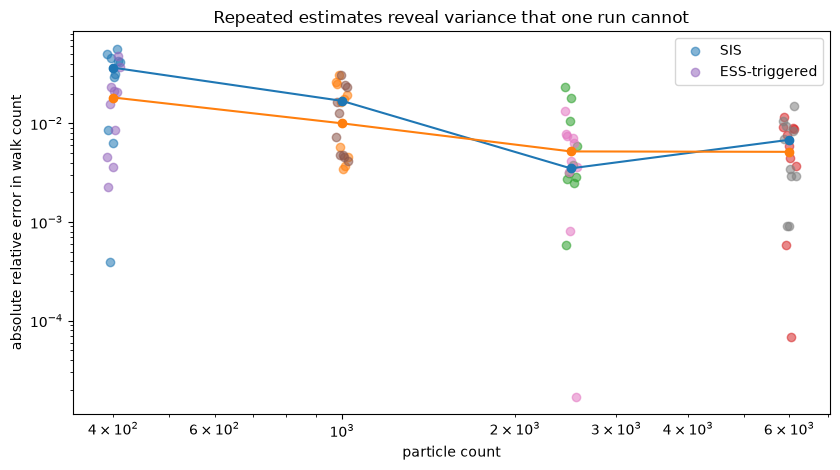

In [10]:
population_grid = np.array([250, 600, 1400] if QUICK_MODE else [400, 1000, 2500, 6000])
repeats = 4 if QUICK_MODE else 10
study = {"SIS": [], "ESS-triggered": []}
study_rngs = iter(spawn_rngs(SEED + 30, 2 * repeats * population_grid.size))

for population in population_grid:
    for _ in range(repeats):
        sis = sample_self_avoiding_walks(
            next(study_rngs), n_steps=walk_steps, n_particles=int(population)
        )
        ess = sample_self_avoiding_walks(
            next(study_rngs),
            n_steps=walk_steps,
            n_particles=int(population),
            resampling="systematic",
            resample_ess_fraction=0.75,
        )
        study["SIS"].append(
            (
                population,
                abs(sis.normalizing_constant_estimate - exact_walk_count) / exact_walk_count,
            )
        )
        study["ESS-triggered"].append(
            (
                population,
                abs(ess.normalizing_constant_estimate - exact_walk_count) / exact_walk_count,
            )
        )

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for name, values in study.items():
    data = np.asarray(values, dtype=np.float64)
    for population in population_grid:
        errors = data[data[:, 0] == population, 1]
        x = population * np.exp(np.linspace(-0.025, 0.025, errors.size))
        ax.scatter(x, errors, alpha=0.55, label=name if population == population_grid[0] else None)
    medians = [np.median(data[data[:, 0] == population, 1]) for population in population_grid]
    ax.plot(population_grid, medians, "o-")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("particle count")
ax.set_ylabel("absolute relative error in walk count")
ax.set_title("Repeated estimates reveal variance that one run cannot")
ax.legend()
finish_figure(fig)

## When to use particle methods

Particle methods are useful when a target is naturally revealed through a sequence of
distributions or partial constructions. They provide normalizing-constant estimates and can
carry multimodal populations, but they require explicit monitoring of weight ESS, resampling
decisions, population size, and ancestry. Resampling solves a local weight problem; it does
not create new information.

Further experiments:

- reorder particles before systematic resampling and measure the change in joint offspring
  behavior;
- compare multinomial and systematic genealogies at equal normalizing-constant error;
- increase walk length until dead paths and weight concentration dominate.


In [11]:
best_error = min(
    abs(result.normalizing_constant_estimate - exact_walk_count) / exact_walk_count
    for result in walk_results.values()
)
assert best_error < (0.30 if QUICK_MODE else 0.12)
assert FIGURE_COUNT >= 6
print(f"completed particle notebook with {FIGURE_COUNT} figures")

completed particle notebook with 6 figures
